In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set(style="whitegrid", font_scale=1.5)
COLORI = {"A pagamento": "#4C72B0", "Free-to-play": "#DD8452"}

dati_puliti = pd.read_parquet("preprocessed/steam_pulito.parquet")
data_raccolta = pd.Timestamp("2026-03-31")

dati = dati_puliti[
    (dati_puliti["Numero di recensioni"] > 0)
    & (dati_puliti["Recensioni positive (%)"] > 0)
    & (dati_puliti["Data di uscita"] <= data_raccolta)
].copy()

dati["Modello di prezzo"] = dati["Prezzo (USD)"].apply(
    lambda prezzo: "Free-to-play" if prezzo == 0 else "A pagamento")
dati["Giocatori per recensione"] = (dati["Giocatori simultanei (picco 24h)"]
                                    / dati["Numero di recensioni"])

a_pagamento = dati[dati["Modello di prezzo"] == "A pagamento"]

# Quanto conta il prezzo su Steam?

## Analisi dei 1000 giochi più venduti

### marzo 2026

---

### *Gabriele Podda*


# Introduzione

## Perché i videogiochi?

- Appassionato ormai da 10 anni


## Perché Steam?

- Una delle principali piattaforme di distribuzione digitale di videogiochi per PC

## Domande

**[D1]** Fra i giochi a pagamento, quelli che costano di più hanno recensioni migliori?

**[D2]** Il punteggio delle recensioni varia fra i generi?

**[D3]** I free-to-play reggono ancora il confronto con i giochi a pagamento?

# I dati

## Fonte

- **Top 1000 Steam Games**, Kaggle, marzo 2026

- costruito da Steam Storefront API e SteamSpy API

## Contenuto

- **Cosa c'è**: prezzo, genere, dati su recensioni e players count (24 hrs)

- **Cosa manca**: vendite effettive, e solo il picco di un giorno anziché una media

## Due colonne da correggere

### Il dataset dichiara i **possessori** di ogni gioco

Il rapporto con il numero di recensioni vale **esattamente 30,0** su tutte e 898 le righe valide.

`possessori = recensioni × 30`

### Il prezzo registrato era quello **del giorno**

**342 titoli su 1000** erano in saldo al momento della raccolta. Ricostruisco il listino: 

`prezzo ÷ (1 − sconto)`.

## **[D1]** Fra i giochi a pagamento, quelli che costano di più hanno recensioni migliori?

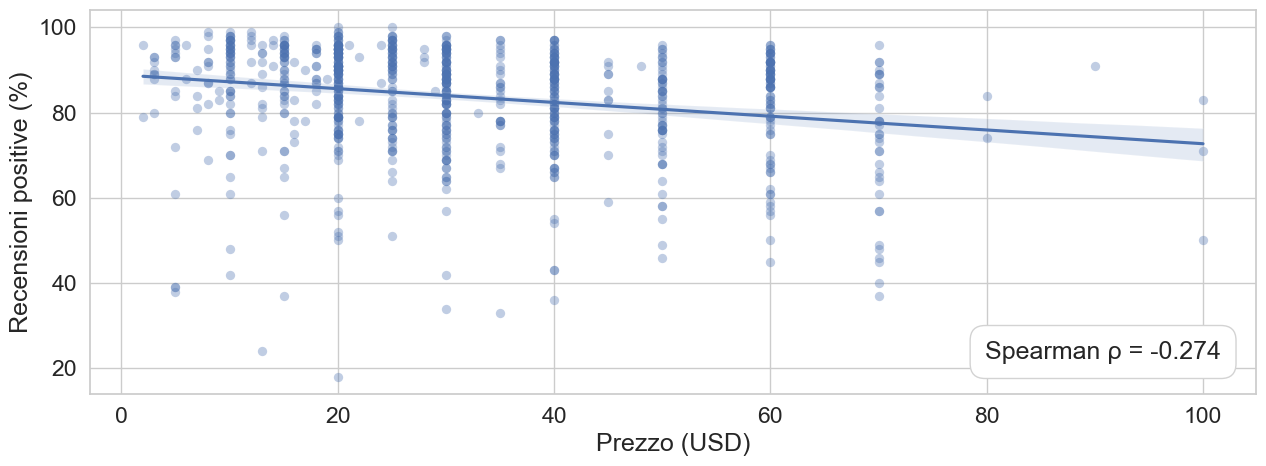

In [2]:
corr_spearman, _ = spearmanr(a_pagamento["Prezzo (USD)"],
                             a_pagamento["Recensioni positive (%)"])

plt.figure(figsize=(13, 5))
sns.regplot(data=a_pagamento, x="Prezzo (USD)", y="Recensioni positive (%)",
            scatter_kws={"s": 45, "alpha": 0.35, "linewidths": 0},
            line_kws={"color": COLORI["A pagamento"]})
plt.annotate(f"Spearman ρ = {corr_spearman:.3f}",
             xy=(0.97, 0.08), xycoords="axes fraction", ha="right", va="bottom",
             bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="lightgrey"))
plt.tight_layout();

**Spearman = −0,27**: all'aumentare del prezzo il gradimento tende a scendere, ma debolmente

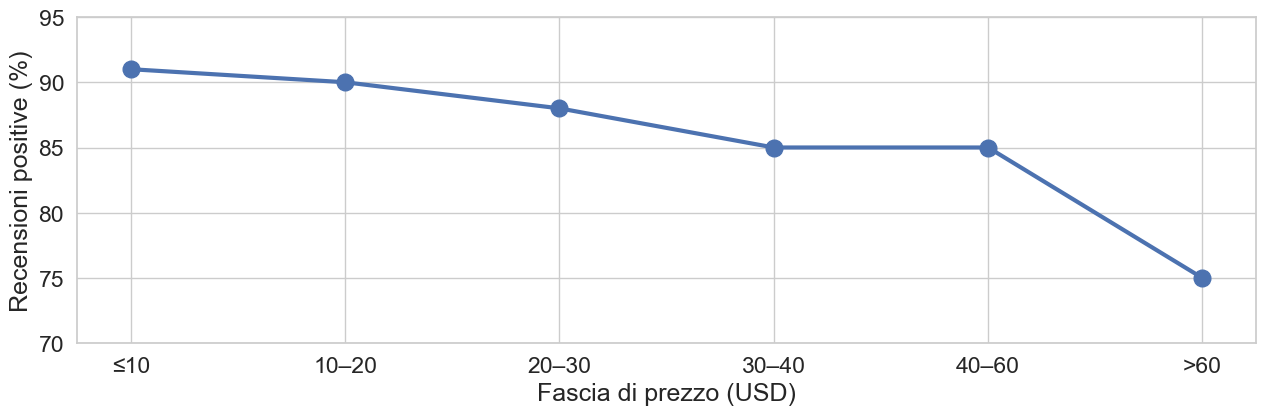

In [3]:
per_fascia = a_pagamento.copy()
per_fascia["Fascia di prezzo (USD)"] = pd.cut(
    per_fascia["Prezzo (USD)"], bins=[0, 10, 20, 30, 40, 60, 100],
    labels=["≤10", "10–20", "20–30", "30–40", "40–60", ">60"])

mediane = (per_fascia.groupby("Fascia di prezzo (USD)", observed=True)
           ["Recensioni positive (%)"].median())

plt.figure(figsize=(13, 4.5))
mediane.plot(marker="o", markersize=12, linewidth=3, color=COLORI["A pagamento"])
plt.ylabel("Recensioni positive (%)")
plt.ylim(70, 95)
plt.tight_layout();

### No, anzi il contrario

dal **91%** sotto i 10 $ al **75%** sopra i 60 \$

## **[D2]** Il punteggio delle recensioni varia fra i generi?

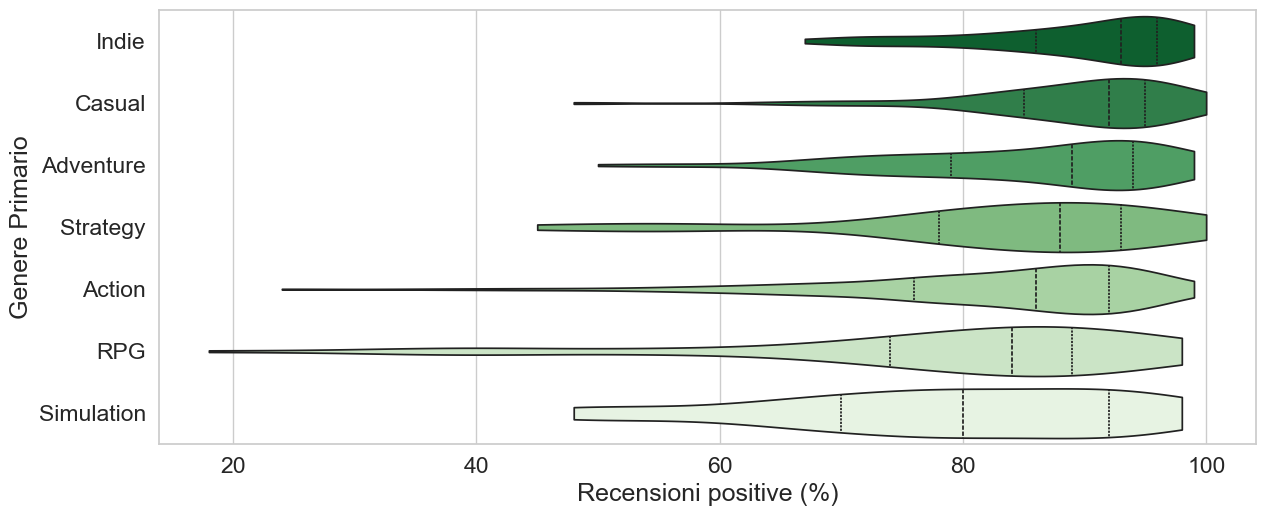

In [4]:
conteggi = dati["Genere Primario"].value_counts()
per_genere = dati[dati["Genere Primario"].isin(conteggi[conteggi >= 20].index)]
ordine = (per_genere.groupby("Genere Primario")["Recensioni positive (%)"]
          .median().sort_values(ascending = False).index.tolist())

plt.figure(figsize=(13, 5.5))
sns.violinplot(data=per_genere, x="Recensioni positive (%)", y="Genere Primario",
               order=ordine, hue="Genere Primario", hue_order=ordine,
               palette=sns.color_palette("Greens_r", len(ordine)),
               legend=False, cut=0, inner="quartile")
plt.tight_layout();

### Sì, di 13 punti percentuali

dall'**80%** di *Simulation* al **93%** di *Indie*

## **[D3]** I free-to-play reggono ancora il confronto con i giochi a pagamento?

### "Reggere" può voler dire due cose

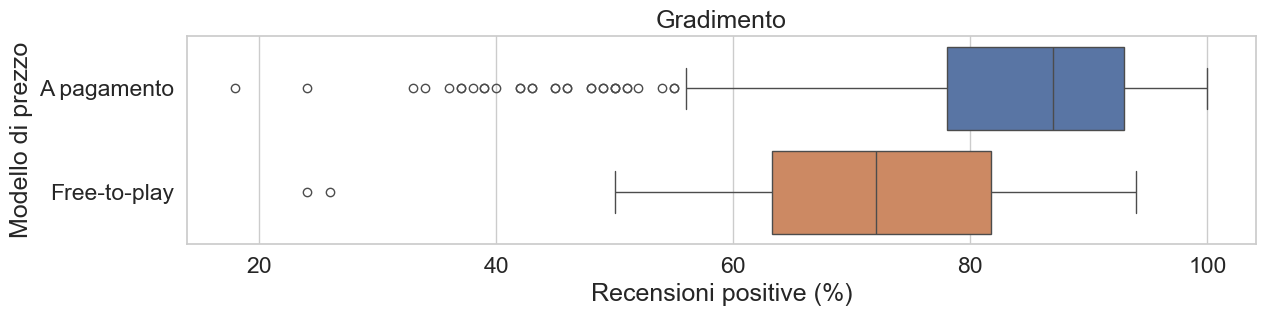

In [5]:
plt.figure(figsize=(13, 3.5))
sns.boxplot(data=dati, x="Recensioni positive (%)", y="Modello di prezzo",
            hue="Modello di prezzo", palette=COLORI, legend=False,
            order=["A pagamento", "Free-to-play"])
plt.title("Gradimento")
plt.tight_layout();

### Gradimento: **no**

mediana **72%** contro **87%**

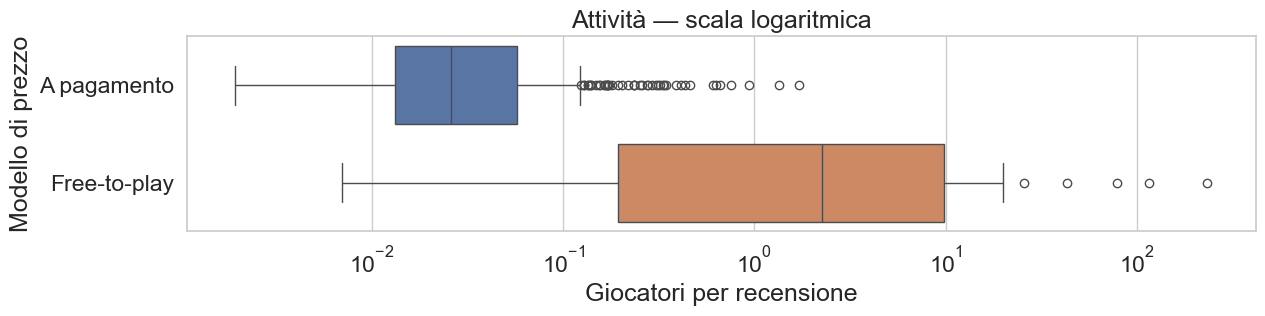

In [6]:
attivi = dati[dati["Giocatori per recensione"] > 0]

plt.figure(figsize=(13, 3.5))
sns.boxplot(data=attivi, x="Giocatori per recensione", y="Modello di prezzo",
            hue="Modello di prezzo", palette=COLORI, legend=False,
            order=["A pagamento", "Free-to-play"])
plt.xscale("log")
plt.title("Attività — scala logaritmica")
plt.tight_layout();

### Attività: **sì**

mediana **87 volte** superiore

# Risposte

### 1. I giochi che costano di più hanno recensioni migliori?
No. Si passa dal **91%** dei titoli sotto i 10 $ al **75%** di quelli sopra i 60, ma la relazione resta debole.

### 2. Il punteggio varia fra i generi?
Sì, di **tredici** punti percentuali: dall'**80%** di *Simulation* al **93%** di *Indie*.

### 3. I free-to-play reggono ancora?
Dipende da cosa si misura: sono valutati **quindici** punti sotto,
ma a parità di pubblico hanno **87** volte più giocatori attivi.